In [1]:
import numpy as np 
import pandas as pd
from dataclasses import dataclass ## for defining datatypes remove the need for defining classes with init functions ##
from typing import List, Dict ## for defining datatypes for lists and dictionaries ##


 ### defining datatypes  ###
@dataclass
class Job:
    id: int
    workload: float
 
@dataclass 
class Node:
    id: int
    speed: float
    cost_per_hour: float
    
    def calculate_time(self, job: Job):
        return job.workload / self.speed
    
    
    

In [2]:
import pandas as pd

def generate_cloud_environment(num_jobs=50, clean_csv="clean_google_jobs.csv"):
    nodes = [
        Node(id=1, speed=1.0, cost_per_hour=0.0116), 
        Node(id=2, speed=2.0, cost_per_hour=0.0208), 
        Node(id=3, speed=4.0, cost_per_hour=0.0340)  
    ]




    # 2. Load the Pre-cleaned Data
    try:
        df = pd.read_csv(clean_csv, nrows=num_jobs)
        
        if len(df) < num_jobs:
            print(f"Warning: The clean CSV only has {len(df)} jobs.")
            
        jobs = []
        for index, row in df.iterrows():
            jobs.append(Job(id=int(row['job_id']), workload=float(row['workload_cu'])))
            
    except FileNotFoundError:
        print(f"Error: '{clean_csv}' not found. Did you run the cleaning script first?")
        return [], []

    return jobs, nodes

# --- Test the Generation ---
jobs, nodes = generate_cloud_environment(num_jobs=20)

print(f"\n--- Empirical Cloud Environment Initialized ---")
print(f"Nodes Available: {len(nodes)}")
print(f"First 5 Google Jobs Loaded:")
for job in jobs[:5]:
    print(f"  Job ID: {job.id}, Workload: {job.workload} Compute Units")


--- Empirical Cloud Environment Initialized ---
Nodes Available: 3
First 5 Google Jobs Loaded:
  Job ID: 0, Workload: 0.0207 Compute Units
  Job ID: 1, Workload: 0.0072 Compute Units
  Job ID: 2, Workload: 0.0486 Compute Units
  Job ID: 3, Workload: 0.0704 Compute Units
  Job ID: 4, Workload: 0.0024 Compute Units


In [3]:
def evaluate_schedule(jobs: List[Job], nodes: List[Node], assignments: List[int]) -> dict:
    """
    Takes a 1D array of assignments and returns the makespan and cost.
    Example assignments: [1, 3, 2] means:
    - job 0 is assigned to node 1
    - job 1 is assigned to node 3
    - job 2 is assigned to node 2

    Args:
        jobs: List of Job objects.
        nodes: List of Node objects.
        assignments: List of node IDs corresponding to each job's assigned node.

    Returns:
        A dictionary with schedule metrics.
    """
    # 1. Create empty queues for each node (using the Node's actual ID)
    node_queues = {node.id: [] for node in nodes}

    # 2. Route the jobs to their assigned nodes
    for job_idx, assigned_node_id in enumerate(assignments):
        current_job = jobs[job_idx]
        node_queues[assigned_node_id].append(current_job)

    total_cost = 0.0
    node_completion_times = {}

    # 3. Process each node's queue
    for node in nodes:
        queue = node_queues[node.id]

        # --- THE LOCAL HEURISTIC (Shortest Job First) ---
        # Sort the queue locally so the smallest workloads run first
        queue.sort(key=lambda j: j.workload)

        node_active_time = 0.0

        # Execute the jobs
        for job in queue:
            execution_time = job.workload / node.speed
            node_active_time += execution_time

        # Calculate cost for this specific node (Convert seconds to hours)
        node_cost = (node_active_time / 3600) * node.cost_per_hour
        total_cost += node_cost

        # Record how long this node took to finish all its work
        node_completion_times[node.id] = node_active_time

    # 4. The Makespan is the time of the node that finishes absolutely last
    makespan = max(node_completion_times.values()) if node_completion_times else 0.0

    return {
        "makespan_seconds": makespan,
        "total_cost_dollars": total_cost,
        "node_details": node_completion_times
    }

In [4]:
# Extract the valid node IDs (1, 2, and 3 from our previous cell)
available_node_ids = [n.id for n in nodes]

# Generate a random schedule (The "Chromosome")
# e.g., randomly assigning each of the 10 jobs to Node 1, 2, or 3
np.random.seed(42) # Keeping it reproducible
random_schedule = np.random.choice(available_node_ids, size=len(jobs))

print(f"Generated Random Schedule (Array):")
print(random_schedule)
print("-" * 40)

# Run the random schedule through our engine
results = evaluate_schedule(jobs, nodes, random_schedule)

print("--- Simulation Results (Random Baseline) ---")
print(f"Makespan (Total Time):   {results['makespan_seconds']:.2f} seconds")
print(f"Total Cloud Cost:        ${results['total_cost_dollars']:.4f}")
print("\nIndividual Node Completion Times:")
for node_id, time_spent in results['node_details'].items():
    print(f"  Node {node_id}: {time_spent:.2f} seconds")

Generated Random Schedule (Array):
[3 1 3 3 1 1 3 2 3 3 3 3 1 3 2 1 2 2 2 2]
----------------------------------------
--- Simulation Results (Random Baseline) ---
Makespan (Total Time):   0.10 seconds
Total Cloud Cost:        $0.0000

Individual Node Completion Times:
  Node 1: 0.10 seconds
  Node 2: 0.03 seconds
  Node 3: 0.08 seconds


In [5]:
import numpy as np

class GeneticAlgorithm:
    
    def __init__(self, jobs, nodes, pop_size=20, generations=100, mutation_rate=0.02, crossover_rate=0.95):
        self.jobs = jobs
        self.nodes = nodes
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.crossover_rate = crossover_rate
        
        self.valid_node_ids = [n.id for n in nodes]
        self.num_jobs = len(jobs)

    def initialize_population(self):
        """Creates a list of random schedules (1D arrays)."""
        return [np.random.choice(self.valid_node_ids, size=self.num_jobs) for _ in range(self.pop_size)]

    def calculate_fitness(self, schedule):
        """
        Our custom Multi-Objective Fitness Function (Makespan + Cost)
        This is an improvement over the paper's Makespan-only fitness function!
        """
        results = evaluate_schedule(self.jobs, self.nodes, schedule)
        fitness_score = results['makespan_seconds'] + (results['total_cost_dollars'] * 100)
        return fitness_score

    def tournament_selection(self, population, fitnesses, k=3):
        selected_indices = np.random.choice(len(population), size=k)
        best_idx = selected_indices[np.argmin([fitnesses[i] for i in selected_indices])]
        return population[best_idx]

    def crossover(self, p1, p2):
        point = np.random.randint(1, self.num_jobs - 1)
        c1 = np.concatenate([p1[:point], p2[point:]])
        c2 = np.concatenate([p2[:point], p1[point:]])
        return c1, c2

    def mutate(self, schedule):
        if np.random.rand() < self.mutation_rate:
            mutation_point = np.random.randint(self.num_jobs)
            new_node = np.random.choice(self.valid_node_ids)
            schedule[mutation_point] = new_node
        return schedule

    def run(self):
        population = self.initialize_population()
        best_overall_schedule = None
        best_overall_fitness = float('inf')
        fitness_history = [] 

        print(f"Starting GA Optimization for {self.generations} generations...")
        
        for gen in range(self.generations):
            fitnesses = [self.calculate_fitness(ind) for ind in population]

            min_idx = np.argmin(fitnesses)
            if fitnesses[min_idx] < best_overall_fitness:
                best_overall_fitness = fitnesses[min_idx]
                best_overall_schedule = population[min_idx]

            fitness_history.append(best_overall_fitness)

            new_pop = []
            new_pop.append(best_overall_schedule) 

            while len(new_pop) < self.pop_size:
                p1 = self.tournament_selection(population, fitnesses)
                p2 = self.tournament_selection(population, fitnesses)
                
                
                
                if np.random.rand() < self.crossover_rate:
                    c1, c2 = self.crossover(p1, p2)
                else:
                    c1, c2 = np.copy(p1), np.copy(p2)
                
                new_pop.append(self.mutate(c1))
                if len(new_pop) < self.pop_size:
                    new_pop.append(self.mutate(c2))

            population = new_pop

        return best_overall_schedule, fitness_history

In [6]:
ga = GeneticAlgorithm(jobs, nodes, pop_size=50, generations=100, mutation_rate=0.2)

best_ai_schedule, learning_history = ga.run()

ai_results = evaluate_schedule(jobs, nodes, best_ai_schedule)


print(f"Final Optimized Schedule Array:\n{best_ai_schedule}\n")

print("--- Final Metrics (AI vs Random Baseline) ---")
print(f"AI Makespan: {ai_results['makespan_seconds']:.2f} sec")
print(f"AI Cost:     ${ai_results['total_cost_dollars']:.4f}")

print("\nAI Node Utilization (Notice how it balances the load):")
for node_id, time_spent in ai_results['node_details'].items():
    print(f"  Node {node_id}: {time_spent:.2f} seconds")

Starting GA Optimization for 100 generations...
Final Optimized Schedule Array:
[2 3 1 3 3 3 2 2 3 3 2 2 3 3 2 3 2 2 1 1]

--- Final Metrics (AI vs Random Baseline) ---
AI Makespan: 0.07 sec
AI Cost:     $0.0000

AI Node Utilization (Notice how it balances the load):
  Node 1: 0.06 seconds
  Node 2: 0.07 seconds
  Node 3: 0.07 seconds


In [8]:
import pandas as pd

def get_advanced_metrics(results, jobs, nodes):
    makespan = results['makespan_seconds']
    num_nodes = len(nodes)
    
    # 1. Resource Utilization (%)
    total_busy_time = sum(results['node_details'].values())
    utilization = (total_busy_time / (makespan * num_nodes)) * 100 if makespan > 0 else 0
    
    # 2. Speedup (T_serial / T_parallel)
    fastest_node = max(nodes, key=lambda n: n.speed)
    serial_time = sum([job.workload / fastest_node.speed for job in jobs])
    speedup = serial_time / makespan if makespan > 0 else 0
    
    # 3. Efficiency (Speedup / N)
    efficiency = speedup / num_nodes if num_nodes > 0 else 0
    
    return utilization, speedup, efficiency



baseline_results = evaluate_schedule(jobs, nodes, random_schedule)
sjf_schedule = greedy_sjf_schedule(jobs, nodes)
sjf_results = evaluate_schedule(jobs, nodes, sjf_schedule)

rand_util, rand_speed, rand_eff = get_advanced_metrics(baseline_results, jobs, nodes)
sjf_util, sjf_speed, sjf_eff = get_advanced_metrics(sjf_results, jobs, nodes)
ai_util, ai_speed, ai_eff = get_advanced_metrics(ai_results, jobs, nodes)

comparison_data = {
    "Algorithm": [
        "1. Random (Baseline)", 
        "2. Pure SJF", 
        "3. GA"
    ],
    "Makespan (s)": [
        baseline_results['makespan_seconds'], 
        sjf_results['makespan_seconds'], 
        ai_results['makespan_seconds']
    ],
    "Cost ($)": [
        baseline_results['total_cost_dollars'], 
        sjf_results['total_cost_dollars'], 
        ai_results['total_cost_dollars']
    ],
    "Utilization (%)": [rand_util, sjf_util, ai_util],
    "Speedup": [rand_speed, sjf_speed, ai_speed],
    "Efficiency": [rand_eff, sjf_eff, ai_eff]
}

df = pd.DataFrame(comparison_data)

print(df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


           Algorithm  Makespan (s)  Cost ($)  Utilization (%)  Speedup  Efficiency
1. Random (Baseline)        0.0965    0.0000          71.8480   1.2275      0.4092
         2. Pure SJF        0.0860    0.0000          62.5279   1.3777      0.4592
               3. GA        0.0686    0.0000          97.5462   1.7267      0.5756


/tmp/ipykernel_5626/2940644416.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(algorithms, rotation=15, ha='right')


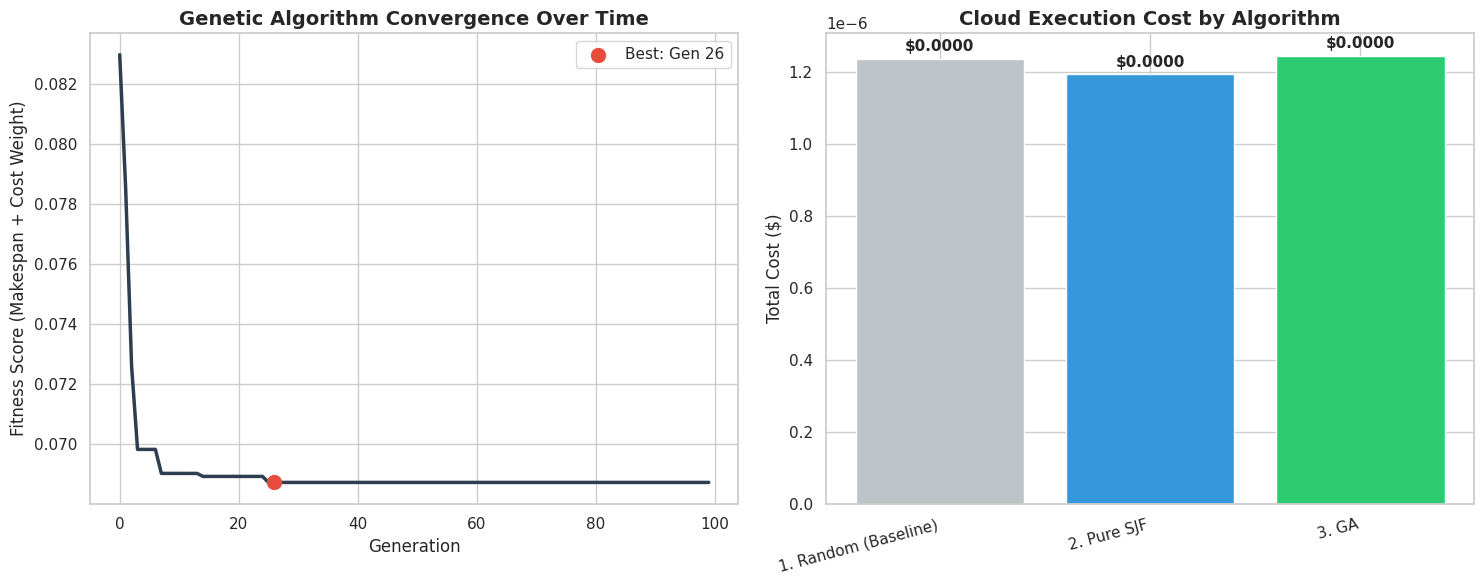

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))


axes[0].plot(learning_history, color='#2c3e50', linewidth=2.5)
axes[0].set_title('Genetic Algorithm Convergence Over Time', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Generation', fontsize=12)
axes[0].set_ylabel('Fitness Score (Makespan + Cost Weight)', fontsize=12)

best_gen = learning_history.index(min(learning_history))
best_score = min(learning_history)
axes[0].scatter(best_gen, best_score, color='#e74c3c', s=100, zorder=5, label=f'Best: Gen {best_gen}')
axes[0].legend()



algorithms = df['Algorithm']
costs = df['Cost ($)']

colors = ['#bdc3c7', '#3498db', '#2ecc71'] # Gray, Blue, Green
bars = axes[1].bar(algorithms, costs, color=colors)

axes[1].set_title('Cloud Execution Cost by Algorithm', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Total Cost ($)', fontsize=12)

axes[1].set_xticklabels(algorithms, rotation=15, ha='right')

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2, yval + (yval * 0.01), f'${yval:.4f}', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# using google 2019 data